In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os
import warnings

In [88]:
'''
# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.
'''

"\n# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축\n1. 과제 개요\n\n  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.\n\n2. 데이터 소스\n\n  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv\n\n  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속\n\n3. 핵심 요구 사항 (평가 기준)\n\n  - 모듈화 설계:\n    - 모든 기능은 독립적인 함수로 작성되어야 하고,\n    - main() 함수에서 제어되어야 함.\n\n  - 데이터 정규화 (Min-Max Scaling):\n    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.\n\n  - 시계열 핸들링:\n    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.\n\n  - 데이터 재구조화:\n    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.\n\n  - 엑셀 내보내기 (To Excel):\n    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.\n"

In [89]:
# 실습 예제 소스와 동일하게 설정
# 환경 및 폰트 설정
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    # print("✅ 환경 설정 및 한글 폰트 로드 완료")

In [90]:
# 경로 설정 및 데이터 소스 로드
def load_data():
  path = 'https://github.com/dongupak/DataML/raw/main/csv/'
  df = pd.read_csv(path + 'weather.csv', encoding='CP949')

  return df # main에서 사용할 수 있도록 데이터 프레임을 리턴함

In [91]:
# 데이터 확인
def check_df(df):
  print(df.head())
  print("----------------------------------------------------------")
  print(df.info())

In [92]:
# 데이터 가공
def preprocess(df):
  # 시계열 핸들링 - 날짜 데이터 변환
  df['일시'] = pd.to_datetime(df['일시'])
  # 인덱스를 '일시' 컬럼으로 설정
  df = df.set_index('일시') # inplace=True 사용 가능

  # 7일 이동 평균 추세선
  season_map = {
      12:'겨울', 1:'겨울', 2:'겨울',
      3:'봄', 4:'봄', 5:'봄',
      6:'여름', 7:'여름', 8:'여름',
      9:'가을', 10:'가을', 11:'가을'
  }
  df['이동평균'] = df['평균기온'].rolling(window=7).mean()
  df['월'] = df.index.month
  df['연도'] = df.index.year
  df['계절'] = df['월'].map(season_map)
  return df

In [93]:
# 데이터 정규화
def min_max_scaling(column):
  result = (column - column.min()) / (column.max() - column.min())
  return result

In [94]:
# 데이터 재구조화
# - pivot_table, groupby
def restructure_data(weather):
  pivot_df = pd.pivot_table(weather, index='연도', columns='계절', values='평균기온', aggfunc='mean')
  groupby_df = weather.groupby('계절')['평균기온'].mean()
  return pivot_df, groupby_df

In [95]:
# 과제 요구 조건 파일(ipynb)에서 그래프가 연달아있는 사진 두 장이었으므로 subplots을 사용하겠습니다.
def graph_1and2(weather):
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 그래프 1 - 기온 시계열 변동 및 추세
  axes[0].plot(weather.index, weather['평균기온'], label='원본', color='grey')
  axes[0].plot(weather.index, weather['이동평균'], label='7일 이동평균', color='red')
  axes[0].set_title('기온 시계열 변동 및 추세')
  axes[0].legend()

  # 그래프 2 - 계절별 기온 분포
  sns.boxplot(x=weather['계절'], y=weather['평균기온'], order=['봄', '여름', '가을', '겨울'], ax=axes[1]) # ax=axes[1] : 오른쪽 칸 (,1)에 그리기
  axes[1].set_title('계절별 기온 분포')

  plt.show()

In [96]:
def graph_3and4(weather, pivot_df):
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  # 그래프 3 - 정규화된 기온 데이터 분포
  sns.histplot(weather['평균기온_scaled'], color='green', kde=True, ax=axes[0])
  axes[0].set_title('정규화된 기온 데이터 분포(Min_Max_Scaled)')
  axes[0].set_xlabel('평균기온')
  axes[0].set_ylabel('Count')

  # 그래프 4 - 연도별/계절별 기온 히트맵
  sns.heatmap(pivot_df, annot=True, cmap='coolwarm', ax=axes[1], fmt='.1f')
  axes[1].set_title('연도별/계절별 기온 히트맵')
  axes[1].set_xlabel('계절')
  axes[1].set_ylabel('Year')

  plt.show()

In [97]:
# 엑셀 파일로 내보내기
# 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀파일의 별도 시트에 저장
def export_to_excel(weather, groupby_df, pivot_df):
  with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
    weather.to_excel(writer, sheet_name='전처리 데이터')
    groupby_df.to_excel(writer, sheet_name='계절별 통계')
    pivot_df.to_excel(writer, sheet_name='연도별 피벗 테이블')

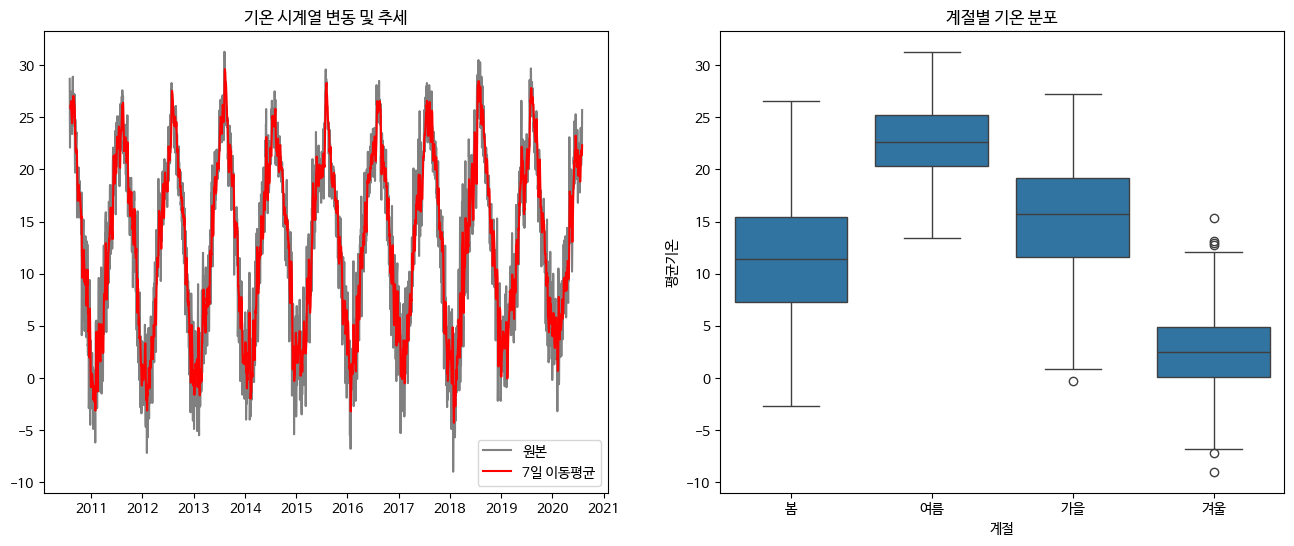

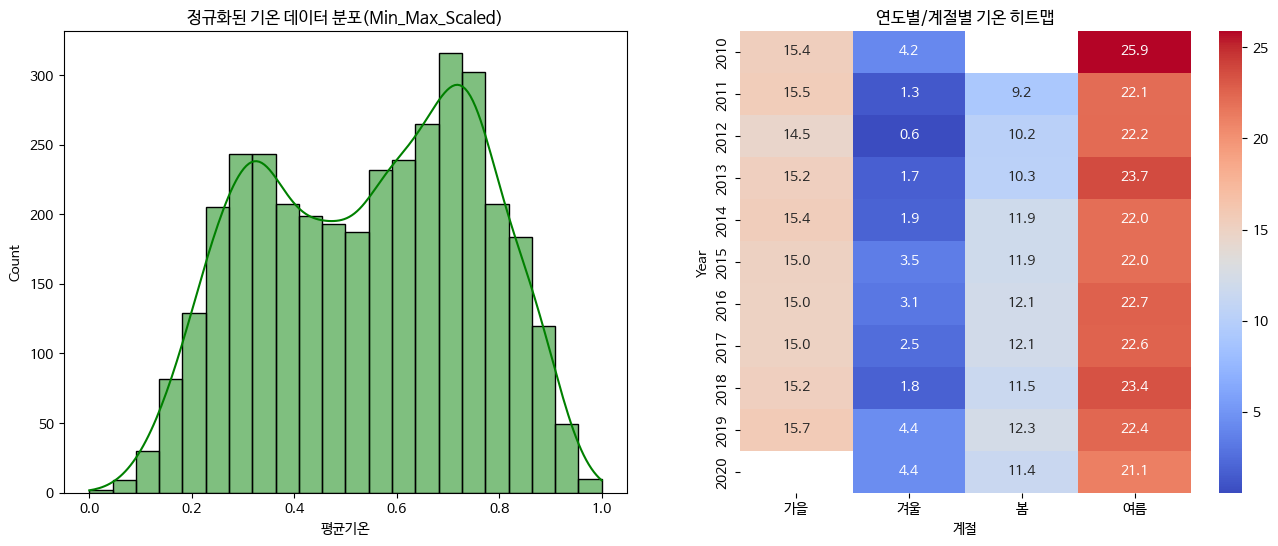

In [98]:
def main():
  setup_environment()
  df = load_data()
  # check_df(df)
  weather = preprocess(df)
  weather['평균기온_scaled'] = min_max_scaling(weather['평균기온'])
  pivot_df, groupby_df = restructure_data(weather)
  graph_1and2(weather)
  graph_3and4(weather, pivot_df)
  export_to_excel(weather, groupby_df, pivot_df)
main()